In [14]:
# installing required libraries in current python environment

import sys
!{sys.executable} -m pip install torch torchvision albumentations opencv-python tqdm fvcore

  Using cached albumentations-2.0.8-py3-none-any.whl.metadata (43 kB)
  Using cached fvcore-0.1.5.post20221221.tar.gz (50 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached albucore-0.0.24-py3-none-any.whl.metadata (5.3 kB)
  Using cached yacs-0.1.8-py3-none-any.whl.metadata (639 bytes)
  Using cached iopath-0.1.10.tar.gz (42 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached portalocker-3.2.0-py3-non

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
# project folder setup

import os

folders = [
    "datasets",
    "src",
    "outputs",
    "outputs/checkpoints",
    "outputs/logs",
    "outputs/predictions"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


In [2]:
# dataset extraction

import zipfile

zip_path = "datasets/archive.zip"
extract_path = "datasets"

if os.path.exists(zip_path):
    print("Dataset zip found.")

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    print("Dataset extracted successfully.")

else:
    print("archive.zip not found in datasets folder.")

Dataset zip found.
Dataset extracted successfully.


In [3]:
# dataset sanity check

voc_path = "datasets/VOC2012_train_val/VOC2012_train_val"

if os.path.exists(voc_path):
    print("VOC dataset found.")

    print("Available folders:")
    print(os.listdir(voc_path))

else:
    print("VOC dataset folder not found. Check extraction.")

VOC dataset found.
Available folders:
['Annotations', 'devkit_doc.pdf', 'ImageSets', 'JPEGImages', 'SegmentationClass', 'SegmentationObject']


In [4]:
# checking dataset folder contents

import os

dataset_root = "datasets"

for root, dirs, files in os.walk(dataset_root):
    print(root)
    break

datasets


In [5]:
# deeper dataset inspection

print(os.listdir("datasets/VOC2012_test/VOC2012_test"))

['Annotations', 'ImageSets', 'JPEGImages']


In [6]:
# verifying installations

import torch
import torchvision
import albumentations

print("Torch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

Torch version: 2.10.0+cpu
Torchvision version: 0.25.0+cpu


In [7]:
# reproducibility setup

import torch
import numpy as np
import random

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

print("Random seeds initialized.")

Random seeds initialized.


In [8]:
# device detection

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [9]:
# inspecting dataset structure

import os

dataset_root = "datasets/VOC2012_train_val/VOC2012_train_val"

print("Dataset root contents:")
print(os.listdir(dataset_root))

Dataset root contents:
['Annotations', 'devkit_doc.pdf', 'ImageSets', 'JPEGImages', 'SegmentationClass', 'SegmentationObject']


In [10]:
# inspecting image folder

image_folder = "datasets/VOC2012_train_val/VOC2012_train_val/JPEGImages"

if os.path.exists(image_folder):
    images = os.listdir(image_folder)
    print("Total images:", len(images))
    print("First 5 images:", images[:5])
else:
    print("JPEGImages folder not found")

Total images: 17125
First 5 images: ['2007_000027.jpg', '2007_000032.jpg', '2007_000033.jpg', '2007_000039.jpg', '2007_000042.jpg']


In [11]:
# inspecting mask folder

mask_folder = "datasets/VOC2012_train_val/VOC2012_train_val/SegmentationClass"

if os.path.exists(mask_folder):
    masks = os.listdir(mask_folder)
    print("Total masks:", len(masks))
    print("First 5 masks:", masks[:5])
else:
    print("SegmentationClass folder not found")

Total masks: 2913
First 5 masks: ['2007_000032.png', '2007_000033.png', '2007_000039.png', '2007_000042.png', '2007_000061.png']


Image shape: (500, 486, 3)
Mask shape: (281, 500)


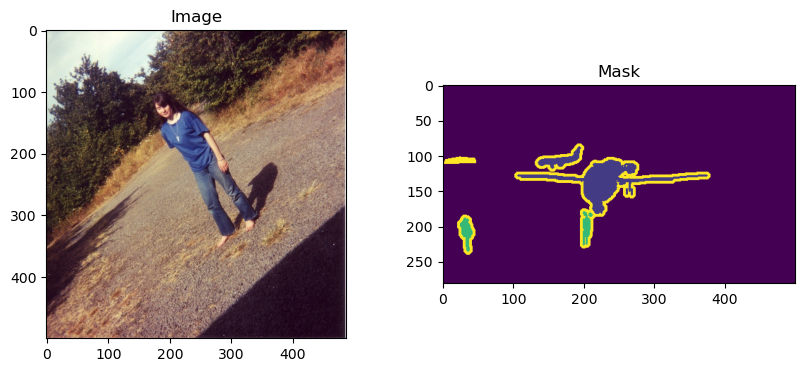

In [12]:
# loading one sample image and mask

import cv2
import matplotlib.pyplot as plt

image_path = os.path.join(image_folder, images[0])
mask_path = os.path.join(mask_folder, masks[0])

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path, 0)

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Image")
plt.imshow(image)

plt.subplot(1,2,2)
plt.title("Mask")
plt.imshow(mask)

plt.show()

In [13]:
# checking segmentation mask folder

import os

mask_folder = "datasets/VOC2012_train_val/VOC2012_train_val"

print(os.listdir(mask_folder))

['Annotations', 'devkit_doc.pdf', 'ImageSets', 'JPEGImages', 'SegmentationClass', 'SegmentationObject']


In [14]:
# verifying mask file exists

import os

image_folder = "datasets/VOC2012_train_val/VOC2012_train_val/JPEGImages"
mask_folder = "datasets/VOC2012_train_val/VOC2012_train_val/SegmentationClass"

image_files = os.listdir(image_folder)

sample_image = image_files[0]
sample_mask = sample_image.replace(".jpg", ".png")

image_path = os.path.join(image_folder, sample_image)
mask_path = os.path.join(mask_folder, sample_mask)

print("Image path:", image_path)
print("Mask path:", mask_path)

print("Does mask exist?", os.path.exists(mask_path))

Image path: datasets/VOC2012_train_val/VOC2012_train_val/JPEGImages\2007_000027.jpg
Mask path: datasets/VOC2012_train_val/VOC2012_train_val/SegmentationClass\2007_000027.png
Does mask exist? False


In [15]:
# correct image-mask pairing sanity check

import os
import cv2
import matplotlib.pyplot as plt

image_folder = "datasets/VOC2012_train_val/VOC2012_train_val/JPEGImages"
mask_folder = "datasets/VOC2012_train_val/VOC2012_train_val/SegmentationClass"

image_files = os.listdir(image_folder)

# pick one image
sample_image = image_files[0]

# convert image name to mask name
sample_mask = sample_image.replace(".jpg", ".png")

image_path = os.path.join(image_folder, sample_image)
mask_path = os.path.join(mask_folder, sample_mask)

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path, 0)

print("Image name:", sample_image)
print("Mask name:", sample_mask)

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Image")
plt.imshow(image)

plt.subplot(1,2,2)
plt.title("Mask")
plt.imshow(mask)

plt.show()

Image name: 2007_000027.jpg
Mask name: 2007_000027.png
Image shape: (500, 486, 3)


AttributeError: 'NoneType' object has no attribute 'shape'

# inspecting segmentation dataset split files

import os

split_folder = "datasets/VOC2012_train_val/VOC2012_train_val/ImageSets/Segmentation"

print(os.listdir(split_folder))

In [16]:
# loading valid segmentation image ids

split_folder = "datasets/VOC2012_train_val/VOC2012_train_val/ImageSets/Segmentation"

train_file = os.path.join(split_folder, "train.txt")

with open(train_file, "r") as f:
    image_ids = f.read().splitlines()

print("Total training images:", len(image_ids))
print("First 5 IDs:", image_ids[:5])

Total training images: 1464
First 5 IDs: ['2007_000032', '2007_000039', '2007_000063', '2007_000068', '2007_000121']


Image shape: (281, 500, 3)
Mask shape: (281, 500)


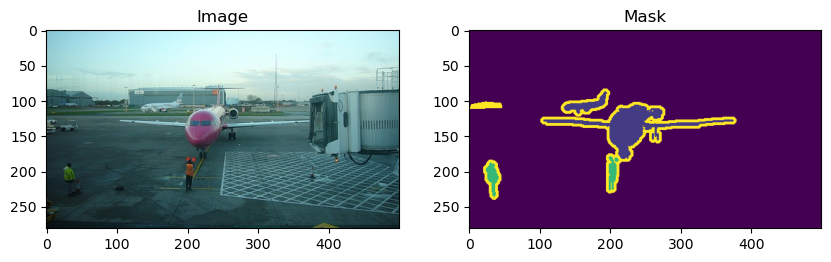

In [17]:
# loading one valid image-mask pair

import cv2
import matplotlib.pyplot as plt

image_folder = "datasets/VOC2012_train_val/VOC2012_train_val/JPEGImages"
mask_folder = "datasets/VOC2012_train_val/VOC2012_train_val/SegmentationClass"

sample_id = image_ids[0]

image_path = os.path.join(image_folder, sample_id + ".jpg")
mask_path = os.path.join(mask_folder, sample_id + ".png")

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path, 0)

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Image")
plt.imshow(image)

plt.subplot(1,2,2)
plt.title("Mask")
plt.imshow(mask)

plt.show()

## PHASE 2: Dataset PreProcessing

In [18]:
# importing libraries for dataset preprocessing

import os
import cv2
import torch
import numpy as np
from sklearn.model_selection import train_test_split

In [19]:
# loading segmentation image ids from VOC split

split_folder = "datasets/VOC2012_train_val/VOC2012_train_val/ImageSets/Segmentation"

trainval_file = os.path.join(split_folder, "trainval.txt")

with open(trainval_file, "r") as f:
    image_ids = f.read().splitlines()

print("Total labeled images:", len(image_ids))
print("First 5 ids:", image_ids[:5])

Total labeled images: 2913
First 5 ids: ['2007_000032', '2007_000033', '2007_000039', '2007_000042', '2007_000061']


In [20]:
# creating train validation split

train_ids, val_ids = train_test_split(
    image_ids,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(train_ids))
print("Validation samples:", len(val_ids))

Training samples: 2330
Validation samples: 583


In [21]:
# resize functions for image and mask

def resize_image(image):

    image = cv2.resize(
        image,
        (300, 300),
        interpolation=cv2.INTER_LINEAR
    )

    return image


def resize_mask(mask):

    mask = cv2.resize(
        mask,
        (300, 300),
        interpolation=cv2.INTER_NEAREST
    )

    return mask

In [22]:
# testing resize functions

image_folder = "datasets/VOC2012_train_val/VOC2012_train_val/JPEGImages"
mask_folder = "datasets/VOC2012_train_val/VOC2012_train_val/SegmentationClass"

sample_id = train_ids[0]

image_path = os.path.join(image_folder, sample_id + ".jpg")
mask_path = os.path.join(mask_folder, sample_id + ".png")

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path, 0)

image_resized = resize_image(image)
mask_resized = resize_mask(mask)

print("Original image:", image.shape)
print("Original mask:", mask.shape)

print("Resized image:", image_resized.shape)
print("Resized mask:", mask_resized.shape)

Original image: (500, 500, 3)
Original mask: (500, 500)
Resized image: (300, 300, 3)
Resized mask: (300, 300)


In [23]:
# checking mask label values

unique_values = np.unique(mask_resized)

print("Mask labels:", unique_values)

Mask labels: [  0  33 220]


## Phase 3 — Robust Data Augmentation

In [24]:
# verifying ignore label presence

print("Unique mask values:", np.unique(mask))

Unique mask values: [  0  33 220]


In [25]:
print("Train samples:", len(train_ids))
print("Validation samples:", len(val_ids))

Train samples: 2330
Validation samples: 583


In [26]:
# importing augmentation libraries

import albumentations as A
from albumentations.pytorch import ToTensorV2

In [27]:
# training augmentation pipeline (updated non-deprecated version)

train_transform = A.Compose(
    [

        A.Resize(300, 300),

        A.HorizontalFlip(p=0.5),

        A.RandomBrightnessContrast(
            brightness_limit=0.2,
            contrast_limit=0.2,
            p=0.5
        ),

        A.GaussNoise(
            std_range=(0.1, 0.2),
            p=0.3
        ),

        A.MotionBlur(
            blur_limit=3,
            p=0.2
        ),

        A.ImageCompression(
            quality_range=(60, 100),
            p=0.3
        ),

        A.Normalize(),

        ToTensorV2()
    ]
)

In [28]:
# validation transformation pipeline

val_transform = A.Compose(
    [
        A.Resize(300, 300),
        A.Normalize(),
        ToTensorV2()
    ]
)

In [29]:
# testing augmentation pipeline

sample_id = train_ids[0]

image_path = os.path.join(image_folder, sample_id + ".jpg")
mask_path = os.path.join(mask_folder, sample_id + ".png")

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path, 0)

augmented = train_transform(image=image, mask=mask)

image_aug = augmented["image"]
mask_aug = augmented["mask"]

print("Augmented image shape:", image_aug.shape)
print("Augmented mask shape:", mask_aug.shape)

Augmented image shape: torch.Size([3, 300, 300])
Augmented mask shape: torch.Size([300, 300])


In [30]:
# fixing python path so notebook can see src folder

import sys
import os

sys.path.append(os.path.abspath("src"))

print("src folder added to python path")

src folder added to python path


In [31]:
# checking current working directory

import os

print("Current directory:")
print(os.getcwd())

print("\nFiles in current directory:")
print(os.listdir())

Current directory:
E:\PYTHON\miniCompetition

Files in current directory:
['.ipynb_checkpoints', 'datasets', 'outputs', 'setup.ipynb', 'src']


In [32]:
# checking src folder

print("Files inside src:")
print(os.listdir("src"))

Files inside src:
['.ipynb_checkpoints', 'dataset.py', 'model.py', '__pycache__']


In [52]:
# importing dataset class

from dataset import VOCDataset

In [53]:
# testing dataset class

from src.dataset import VOCDataset

train_dataset = VOCDataset(
    train_ids,
    image_folder,
    mask_folder,
    transform=train_transform
)

print("Dataset size:", len(train_dataset))

Dataset size: 2330


In [54]:
# testing dataset sample

image, mask = train_dataset[0]

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)

Image shape: torch.Size([3, 300, 300])
Mask shape: torch.Size([300, 300])


## Phase 5 — DataLoader

In [36]:
# importing dataloader

from torch.utils.data import DataLoader

In [37]:
# creating training dataset

train_dataset = VOCDataset(
    train_ids,
    image_folder,
    mask_folder,
    transform=train_transform
)

In [38]:
# creating validation dataset

val_dataset = VOCDataset(
    val_ids,
    image_folder,
    mask_folder,
    transform=val_transform
)

In [39]:
# creating dataloaders

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

In [40]:
# testing dataloader

images, masks = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch mask shape:", masks.shape)

Batch image shape: torch.Size([16, 3, 300, 300])
Batch mask shape: torch.Size([16, 300, 300])


## Phase 6 — Model Architecture

In [41]:
# importing model

from src.model import UNet

In [42]:
# creating model

model = UNet(num_classes=21)

print(model)

UNet(
  (enc1): EncoderBlock(
    (conv): DepthwiseSeparableConv(
      (depthwise): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=3)
      (pointwise): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1))
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (enc2): EncoderBlock(
    (conv): DepthwiseSeparableConv(
      (depthwise): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32)
      (pointwise): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (enc3): EncoderBlock(
    (conv): DepthwiseSeparableConv(
      (depthwise): Conv2d(64, 64, kernel_siz

In [46]:
# sanity check: testing model forward pass

dummy = torch.randn(1,3,300,300)

output = model(dummy)

print("Output shape:", output.shape)

Output shape: torch.Size([1, 21, 300, 300])


In [43]:
# reload model module

import importlib
import src.model

importlib.reload(src.model)

from src.model import UNet

In [44]:
# recreate model

model = UNet(num_classes=21)

In [45]:
# testing model forward pass

import torch

dummy = torch.randn(1,3,300,300)

output = model(dummy)

print("Output shape:", output.shape)

Output shape: torch.Size([1, 21, 300, 300])


## Phase 7 — Loss Functions & Dice Metric

In [47]:
# testing loss function

from src.loss import CombinedLoss

criterion = CombinedLoss()

dummy_pred = torch.randn(2,21,300,300)
dummy_mask = torch.randint(0,21,(2,300,300))

loss = criterion(dummy_pred, dummy_mask)

print("Loss value:", loss.item())

Loss value: 4.4574480056762695


In [49]:
# testing dice metric

from src.metrics import dice_score

dummy_pred = torch.randn(2,21,300,300)
dummy_mask = torch.randint(0,21,(2,300,300))

score = dice_score(dummy_pred, dummy_mask)

print("Dice score:", score)

Dice score: 0.048138681799173355


## Phase 8: Training Pipeline

## Phase 9: FLOPs Calculation

In [51]:
!python src/flops.py

Total FLOPs: 1252174832
FLOPs (GFLOPs): 1.252174832


Unsupported operator aten::max_pool2d encountered 3 time(s)


## Phase 10 — Inference Script